In [ ]:
!pip install torch torch-geometric -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install rdkit deepchem
!pip install pandas
!pip install tqdm tabulate

In [1]:
import pandas as pd
from rdkit import Chem
from torch_geometric.data import Data
import torch
from tqdm import tqdm
from tabulate import tabulate
import deepchem as dc

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [2]:
def load_dataset(path='cleanData.xlsx'):
    df = pd.read_excel(path)
    df = df.dropna(subset=['SMILES', 'single-class-label'])
    return df

dataset_df = load_dataset()
print(f"Loaded {len(dataset_df)} molecules.")

# transfer to list to make it compatible with featurizer
smiles_list = dataset_df['SMILES'].tolist()
labels = dataset_df['single-class-label'].tolist()

print("5 example of SMILES", smiles_list[:5])
print("Class of the 5 example smiles", labels[:5])

Loaded 4075 molecules.
5 example of SMILES ['CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1', 'O=C(CCCCC1CCSS1)NCCCNc1c2c(nc3cc(Cl)ccc13)CCCC2', 'COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2', 'CNC(=O)Oc1cccc(CN(C)CCCOc2ccc3c(=O)c4ccccc4oc3c2)c1', 'CCC1=CC2Cc3nc4cc(Cl)ccc4c(N)c3[C@@H](C1)C2']
Class of the 5 example smiles [1, 1, 1, 1, 1]


In [3]:
# pair SMILES list to corresponding label
valid_data = []
invalid_smiles = []

for smiles, label in tqdm(zip(smiles_list, labels), total=len(smiles_list), desc="Validating and converting SMILES"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
      valid_data.append((mol, smiles, label))
    else:
      invalid_smiles.append(smiles)

print("\n\nNumber of valid SMILES", len(valid_data))
print("5 example of valid data", valid_data[:5])
print("\nNumber of invalid SMILES:", len(invalid_smiles))
print("5 example of invalid SMILES", invalid_smiles[:5])

# Unzip list to tuple
mol, filtered_smiles_list, filtered_labels = zip(*valid_data)

print("\n5 examples of filtered_smiles_list tuple: ", filtered_smiles_list[:5])
print("corresponding label (in tuple): ", filtered_labels[:5])

NameError: name 'tqdm' is not defined

╒════════════════════════════════════════════════════════════════════╤═════════╤═══════════════╤═══════════════╤═════════════╕
│ SMILES                                                             │   Label │ Formula       │   Mol. Weight │   Num Atoms │
╞════════════════════════════════════════════════════════════════════╪═════════╪═══════════════╪═══════════════╪═════════════╡
│ CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1                                   │       1 │ C12H19N2O2+   │        223.3  │          16 │
├────────────────────────────────────────────────────────────────────┼─────────┼───────────────┼───────────────┼─────────────┤
│ O=C(CCCCC1CCSS1)NCCCNc1c2c(nc3cc(Cl)ccc13)CCCC2                    │       1 │ C24H32ClN3OS2 │        478.13 │          31 │
├────────────────────────────────────────────────────────────────────┼─────────┼───────────────┼───────────────┼─────────────┤
│ COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2 │       1 │ C33H40ClN3O3  │        562.15 

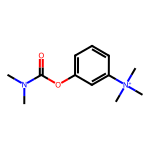

Molecule 2


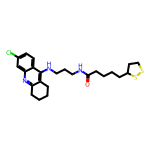

Molecule 3


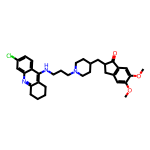

Molecule 4


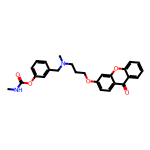

Molecule 5


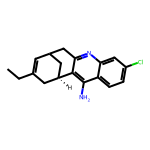

In [ ]:
# Just to explain what is smiles

from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from tabulate import tabulate
from IPython.display import display
from PIL import Image
import io

valid_data_table = []
images = []

for mol_obj, smiles, label in valid_data[:5]:
    formula = rdMolDescriptors.CalcMolFormula(mol_obj)
    mw = Descriptors.MolWt(mol_obj)
    num_atoms = mol_obj.GetNumAtoms()

    # Create PIL image of molecule
    img = Draw.MolToImage(mol_obj, size=(150,150))
    images.append(img)

    # Add data row without the image (tabulate can’t embed images)
    valid_data_table.append([smiles, label, formula, f"{mw:.2f}", num_atoms])

# Print the table (without images)
print(tabulate(valid_data_table, headers=["SMILES", "Label", "Formula", "Mol. Weight", "Num Atoms"], tablefmt="fancy_grid"))

# Display images separately below the table with labels
print("\nMolecule drawings:")
for i, img in enumerate(images):
    print(f"Molecule {i+1}")
    display(img)

In [ ]:
from sklearn.model_selection import train_test_split

# Split to train and test set by 80-20
smiles_train, smiles_temp, labels_train, labels_temp = train_test_split(
    filtered_smiles_list, filtered_labels, test_size=0.2, train_size=0.8, random_state=42, stratify=filtered_labels
)

# Further split test set to test-validation set to 10-10
smiles_test, smiles_val, labels_test, labels_val = train_test_split(
    smiles_temp, labels_temp, test_size=0.5, random_state=42, stratify=labels_temp
)

Memo: try without stratified later

In [ ]:
def convmol_to_pyg(smiles_list, labels=None):
    featurizer = dc.feat.ConvMolFeaturizer()
    convmols = featurizer.featurize(smiles_list)

    data_list = []

    for idx, convmol in enumerate(convmols):
        if convmol is None:
            continue  # Skip failed molecules

        x = torch.tensor(convmol.get_atom_features(), dtype=torch.float)

        edge_list = []
        for start_idx, neighbors in enumerate(convmol.get_adjacency_list()):
            for end_idx in neighbors:
                edge_list.append((start_idx, end_idx))

        if len(edge_list) > 0:
            edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)  # No bonds

        if labels is not None:
            y = torch.tensor([labels[idx]], dtype=torch.long)
            data = Data(x=x, edge_index=edge_index, y=y, smiles=smiles_list[idx])  # Store SMILES
        else:
            data = Data(x=x, edge_index=edge_index, smiles=smiles_list[idx])  # Store SMILES

        data_list.append(data)

    return data_list

In [ ]:
train_graphs = convmol_to_pyg(smiles_train, labels_train)
val_graphs   = convmol_to_pyg(smiles_val, labels_val)
test_graphs  = convmol_to_pyg(smiles_test, labels_test)

Streaming output truncated to the last 5000 lines.
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:11] DEPRECATION WARNING: please use GetValence(getExplicit=False)


In [ ]:
data_list = convmol_to_pyg(smiles_list, labels)
data = data_list[0]  # first molecule
print("SMILES:", data.smiles)
print("Label:", data.y.item() if hasattr(data, "y") else "No label")
print("Atom features shape:", data.x.shape)
print("Atom features (first few rows):\n", data.x[:5])

Streaming output truncated to the last 5000 lines.
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:16:21] DEPRECATION WARNING: please use GetValence(getExplicit=False)


SMILES: CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1
Label: 1
Atom features shape: torch.Size([16, 75])
Atom features (first few rows):
 tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 

In [ ]:
data = data_list[0]
print("SMILES:", data.smiles)
print("Label:", data.y.item() if hasattr(data, "y") else "No label")
print("Atom features shape:", data.x.shape)
print("Atom features (first few rows):\n", data.x[:5])

SMILES: CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1
Label: 1
Atom features shape: torch.Size([16, 75])
Atom features (first few rows):
 tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 

# convert the ConvMol outputs into PyG Data objects

From ConvMolFeaturizer:

* nodes (numpy array): shape [num_atoms, num_features]

* edges (list of neighbor indices): adjacency list

Convert into:

* x = tensor(nodes)

* edge_index = tensor(edge list in COO format)

Train, test, val ratio: 80%, 10%, 10%

In [ ]:
print(f"Train graphs: {len(train_graphs)}, Test graphs: {len(test_graphs)}, Validation graphs: {len(val_graphs)}")

# DataLoader
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32)
val_loader = DataLoader(val_graphs, batch_size=32)
print(f"Number of train set batches: {len(train_loader)}, Number of test set batches: {len(test_loader)}, Number of validation set batches: {len(val_loader)}")

Train graphs: 3260, Test graphs: 407, Validation graphs: 408
Number of train set batches: 102, Number of test set batches: 13, Number of validation set batches: 13


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, global_mean_pool

class DeepChemStyleGraphConv(nn.Module):
    def __init__(self,
                 node_feat_dim=75,
                 hidden_dims=[64, 64],
                 dense_dim=128,
                 dropout_rate=0.25,
                 n_classes=2,
                 batch_norm=True):
        super(DeepChemStyleGraphConv, self).__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList() if batch_norm else None

        # GraphConv layers
        in_channels = node_feat_dim
        for hidden_dim in hidden_dims:
            self.convs.append(GraphConv(in_channels, hidden_dim))
            if batch_norm:
                self.bns.append(nn.BatchNorm1d(hidden_dim))
            in_channels = hidden_dim

        # Dense layers after pooling
        self.fc1 = nn.Linear(in_channels, dense_dim)
        self.fc2 = nn.Linear(dense_dim, n_classes)

        self.dropout_rate = dropout_rate
        self.batch_norm = batch_norm

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if self.batch_norm:
                x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout_rate, training=self.training)

        # Global pooling
        x = global_mean_pool(x, batch)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        logits = self.fc2(x)

        return logits

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os


def train_one_epoch(model, optimizer, criterion, loader, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


def evaluate_model(model, loader, device, is_binary=True, criterion=None):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            if criterion is not None:
                loss = criterion(out, data.y)
                total_loss += loss.item() * data.num_graphs

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu()[:, 1] if is_binary else probs.cpu())
            all_labels.append(data.y.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='binary' if is_binary else 'macro')
    roc_auc = roc_auc_score(y_true, y_prob) if is_binary else roc_auc_score(y_true, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)

    val_loss = total_loss / len(loader.dataset) if criterion is not None else None

    return acc, f1, roc_auc, cm, report, val_loss


def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    # Plot F1 / Accuracy / AUC
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_f1'], label='Val F1')
    plt.plot(epochs, history['val_acc'], label='Val Accuracy')
    plt.plot(epochs, history['val_auc'], label='Val AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Validation Metrics over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

def run_training_loop(model, optimizer, criterion,
                      train_loader, val_loader, device,
                      num_epochs=30, save_path='best_model.pt',
                      is_binary=True, monitor_metric='f1',
                      csv_path='training_history.csv'):
    best_metric = -float('inf')
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': [], 'val_auc': []}
    best_results = {}

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)
        acc, f1, roc_auc, cm, report, val_loss = evaluate_model(model, val_loader, device, is_binary, criterion)

        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(f1)
        history['val_acc'].append(acc)
        history['val_auc'].append(roc_auc)

        print(f"[Epoch {epoch}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}")

        # Save best model
        metric = {'f1': f1, 'auc': roc_auc, 'acc': acc}[monitor_metric]
        if metric > best_metric:
            best_metric = metric
            best_results = {'acc': acc, 'f1': f1, 'roc_auc': roc_auc, 'cm': cm, 'report': report}
            torch.save(model.state_dict(), save_path)
            print(f"✅ Saved new best model (epoch {epoch})")

    # Final results
    print("\n📊 Final Best Validation Metrics:")
    print(f"Accuracy: {best_results['acc']:.4f}")
    print(f"F1 Score: {best_results['f1']:.4f}")
    print(f"AUC-ROC: {best_results['roc_auc']:.4f}")
    print("\nClassification Report:\n", best_results['report'])
    plot_confusion_matrix(best_results['cm'], class_names=['0', '1'])

    # Plot curves
    plot_training_history(history)

    # Save to CSV
    df_history = pd.DataFrame(history)
    df_history.to_csv(csv_path, index_label='epoch')
    print(f"📁 Training history saved to {csv_path}")

    return history

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau # Import for LR scheduler

def run_training_loop_with_early_stopping(
    model, optimizer, criterion,
    train_loader, val_loader, device,
    num_epochs=100,
    save_path='best_model.pt',
    is_binary=True,
    monitor_metric='auc', # Default to AUC for stability
    early_stopping_patience=25, # New: How many epochs to wait for improvement
    lr_scheduler_patience=10, # New: How many epochs for LR reduction
    lr_scheduler_factor=0.5, # New: Factor to reduce LR
    csv_path='training_history.csv'
):
    # Initialize variables for early stopping and best model tracking
    best_metric_val = -float('inf') # Use -inf for metrics where 'higher is better'
    best_epoch = -1
    epochs_no_improve = 0 # Counter for early stopping patience
    best_results_overall = {} # Store results for the truly best model

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': [], 'val_auc': []}

    # Initialize Learning Rate Scheduler
    # Monitor the same metric as early stopping for consistency
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max' if monitor_metric != 'val_loss' else 'min', # 'max' for AUC, F1, Acc; 'min' for Loss
        factor=lr_scheduler_factor,
        patience=lr_scheduler_patience,
        verbose=True
    )

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)
        acc, f1, roc_auc, cm, report, val_loss = evaluate_model(model, val_loader, device, is_binary, criterion)

        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(f1)
        history['val_acc'].append(acc)
        history['val_auc'].append(roc_auc)

        print(f"[Epoch {epoch}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}")

        # Determine the current metric value to monitor
        if monitor_metric == 'auc':
            current_monitor_metric = roc_auc
        elif monitor_metric == 'f1':
            current_monitor_metric = f1
        elif monitor_metric == 'acc':
            current_monitor_metric = acc
        elif monitor_metric == 'val_loss':
            current_monitor_metric = -val_loss # Invert loss because early stopping usually monitors for 'max' value for consistency

        # Check for improvement and save best model
        if current_monitor_metric > best_metric_val:
            best_metric_val = current_monitor_metric
            best_epoch = epoch
            best_results_overall = {
                'acc': acc, 'f1': f1, 'roc_auc': roc_auc,
                'cm': cm, 'report': report, 'val_loss': val_loss,
                'epoch': epoch # Store the epoch where the best results occurred
            }
            torch.save(model.state_dict(), save_path)
            print(f"✅ Saved new best model (epoch {epoch}) - {monitor_metric}: {best_metric_val:.4f}")
            epochs_no_improve = 0 # Reset patience counter
        else:
            epochs_no_improve += 1 # Increment patience counter
            print(f" No improvement in {monitor_metric}. Patience: {epochs_no_improve}/{early_stopping_patience}")

        # Step the learning rate scheduler
        scheduler.step(current_monitor_metric)

        # Check early stopping condition
        if epochs_no_improve >= early_stopping_patience:
            print(f"\n🛑 Early stopping triggered after {early_stopping_patience} epochs without improvement in {monitor_metric}.")
            break # Exit the training loop

    # Final results based on the best saved model
    print("\n📊 Final Best Validation Metrics (from epoch {}):".format(best_results_overall.get('epoch', 'N/A')))
    print(f"Accuracy: {best_results_overall['acc']:.4f}")
    print(f"F1 Score: {best_results_overall['f1']:.4f}")
    print(f"AUC-ROC: {best_results_overall['roc_auc']:.4f}")
    print("\nClassification Report:\n", best_results_overall['report'])
    plot_confusion_matrix(best_results_overall['cm'], class_names=['0', '1'])

    # Plot curves
    plot_training_history(history)

    # Save to CSV
    df_history = pd.DataFrame(history)
    df_history.to_csv(csv_path, index_label='epoch')
    print(f"📁 Training history saved to {csv_path}")

    return history

[Epoch 1] Train Loss: 0.6406 | Val Loss: 0.6053 | Acc: 0.6618 | F1: 0.6080 | AUC: 0.7255
✅ Saved new best model (epoch 1) - f1: 0.6080
[Epoch 2] Train Loss: 0.5982 | Val Loss: 0.5732 | Acc: 0.6887 | F1: 0.6319 | AUC: 0.7659
✅ Saved new best model (epoch 2) - f1: 0.6319
[Epoch 3] Train Loss: 0.5742 | Val Loss: 0.5555 | Acc: 0.7108 | F1: 0.6144 | AUC: 0.7970
🤷 No improvement in f1. Patience: 1/25
[Epoch 4] Train Loss: 0.5513 | Val Loss: 0.5371 | Acc: 0.7377 | F1: 0.6748 | AUC: 0.8119
✅ Saved new best model (epoch 4) - f1: 0.6748
[Epoch 5] Train Loss: 0.5353 | Val Loss: 0.5178 | Acc: 0.7377 | F1: 0.6952 | AUC: 0.8239
✅ Saved new best model (epoch 5) - f1: 0.6952
[Epoch 6] Train Loss: 0.5292 | Val Loss: 0.5348 | Acc: 0.7132 | F1: 0.7181 | AUC: 0.8162
✅ Saved new best model (epoch 6) - f1: 0.7181
[Epoch 7] Train Loss: 0.5155 | Val Loss: 0.5021 | Acc: 0.7426 | F1: 0.7059 | AUC: 0.8346
🤷 No improvement in f1. Patience: 1/25
[Epoch 8] Train Loss: 0.5164 | Val Loss: 0.4947 | Acc: 0.7525 | F1: 0

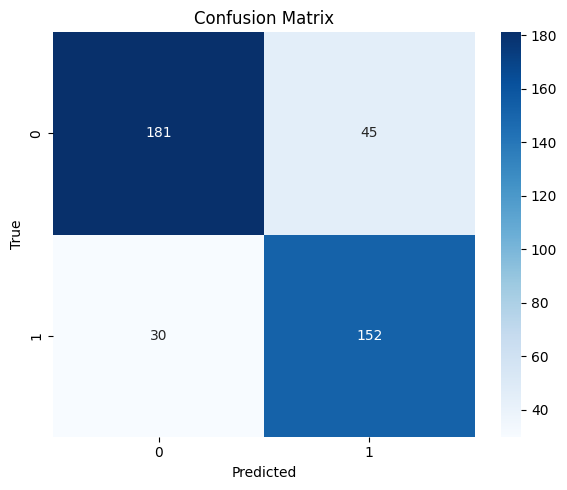

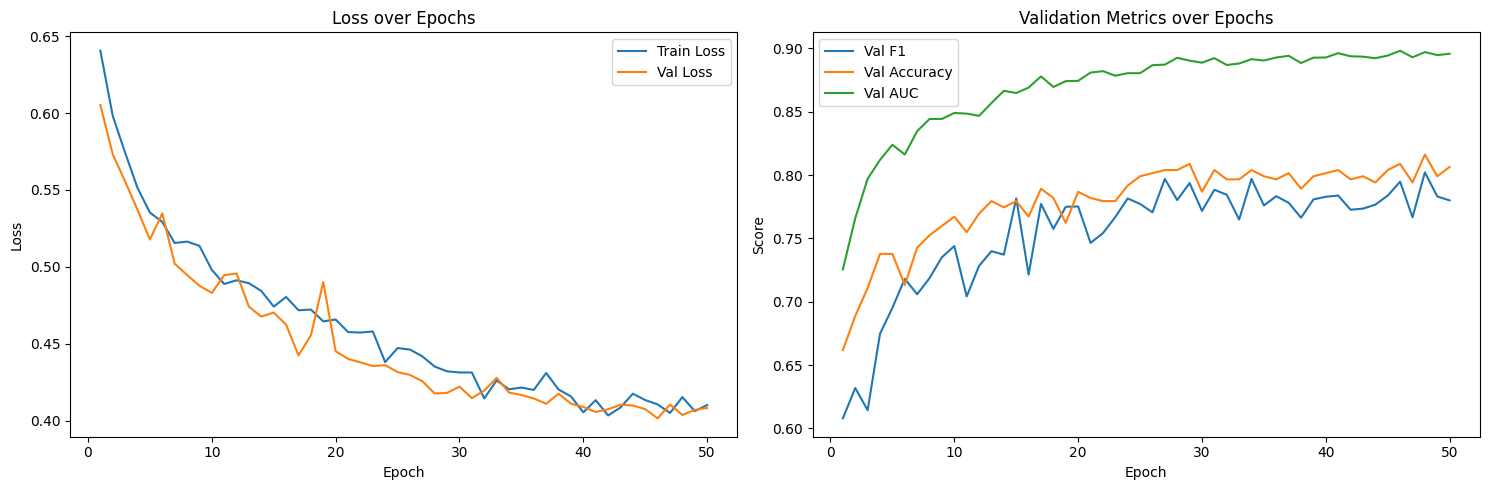

📁 Training history saved to training_history.csv


In [ ]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate model
model = DeepChemStyleGraphConv(node_feat_dim=75, n_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Assume now we have:
# model, optimizer, criterion, train_loader, val_loader, device

history = run_training_loop_with_early_stopping(
    model=model,
    optimizer=optimizer,
    criterion=torch.nn.CrossEntropyLoss(),
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=50,
    save_path='earlyStop50.pt',
    is_binary=True,
    monitor_metric='f1'  # could also be 'auc' or 'acc'
)


====================== Fold 1 ======================


Streaming output truncated to the last 5000 lines.
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:27:52] DEPRECATION WARNING: please use GetValence(getExplicit=False)


[Epoch 1] Train Loss: 0.6368 | Val Loss: 0.6088 | Acc: 0.6589 | F1: 0.6273 | AUC: 0.7274
✅ Saved new best model (epoch 1) - f1: 0.6273
[Epoch 2] Train Loss: 0.5915 | Val Loss: 0.5736 | Acc: 0.6834 | F1: 0.6217 | AUC: 0.7691
🤷 No improvement in f1. Patience: 1/15
[Epoch 3] Train Loss: 0.5662 | Val Loss: 0.5531 | Acc: 0.7190 | F1: 0.6943 | AUC: 0.7918
✅ Saved new best model (epoch 3) - f1: 0.6943
[Epoch 4] Train Loss: 0.5456 | Val Loss: 0.5284 | Acc: 0.7423 | F1: 0.7067 | AUC: 0.8137
✅ Saved new best model (epoch 4) - f1: 0.7067
[Epoch 5] Train Loss: 0.5290 | Val Loss: 0.5280 | Acc: 0.7264 | F1: 0.6819 | AUC: 0.8118
🤷 No improvement in f1. Patience: 1/15
[Epoch 6] Train Loss: 0.5176 | Val Loss: 0.5245 | Acc: 0.7288 | F1: 0.6563 | AUC: 0.8276
🤷 No improvement in f1. Patience: 2/15
[Epoch 7] Train Loss: 0.5130 | Val Loss: 0.5002 | Acc: 0.7632 | F1: 0.7503 | AUC: 0.8343
✅ Saved new best model (epoch 7) - f1: 0.7503
[Epoch 8] Train Loss: 0.5069 | Val Loss: 0.4928 | Acc: 0.7583 | F1: 0.7334 |

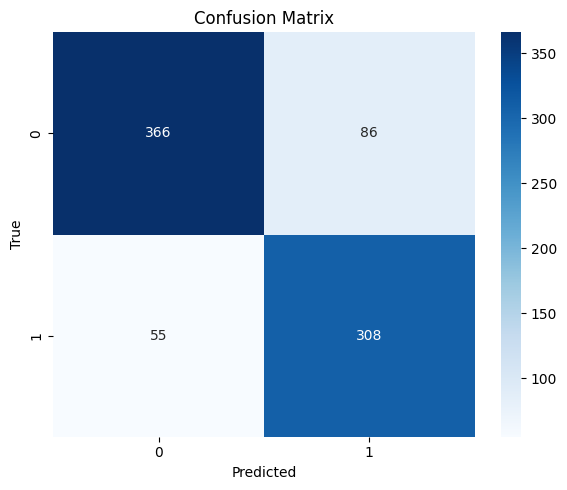

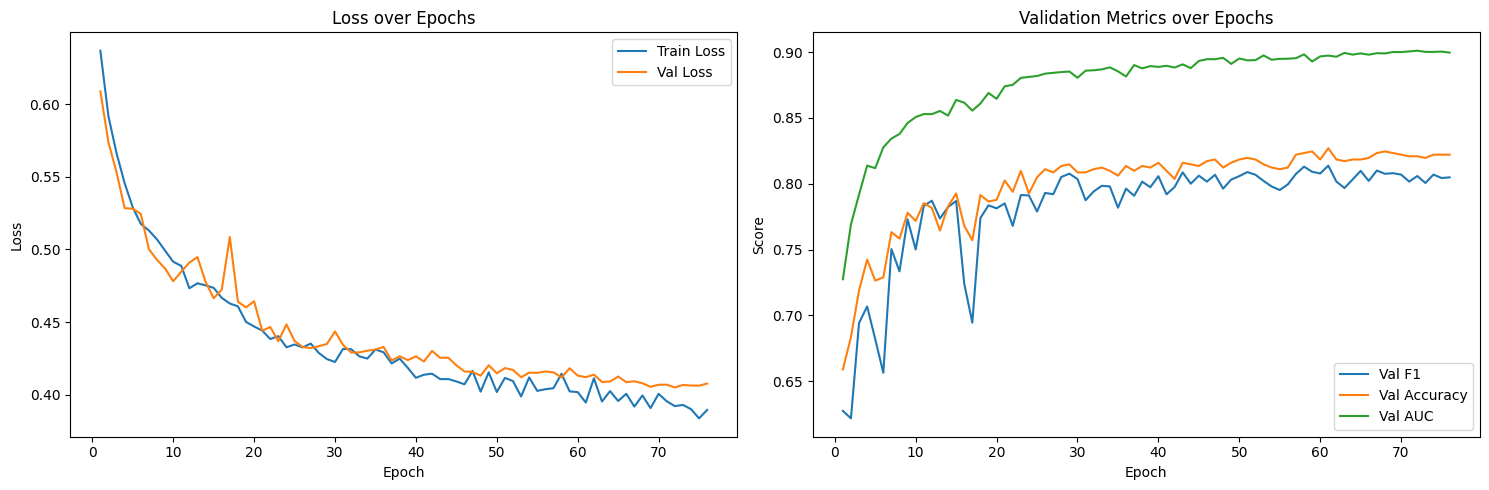

📁 Training history saved to training_history_fold1.csv

====================== Fold 2 ======================


Streaming output truncated to the last 5000 lines.
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:28:57] DEPRECATION WARNING: please use GetValence(getExplicit=False)


[Epoch 1] Train Loss: 0.6452 | Val Loss: 0.6196 | Acc: 0.6577 | F1: 0.6391 | AUC: 0.7268
✅ Saved new best model (epoch 1) - f1: 0.6391
[Epoch 2] Train Loss: 0.5949 | Val Loss: 0.5873 | Acc: 0.6724 | F1: 0.5659 | AUC: 0.7576
🤷 No improvement in f1. Patience: 1/15
[Epoch 3] Train Loss: 0.5693 | Val Loss: 0.5780 | Acc: 0.7178 | F1: 0.7242 | AUC: 0.7845
✅ Saved new best model (epoch 3) - f1: 0.7242
[Epoch 4] Train Loss: 0.5584 | Val Loss: 0.5391 | Acc: 0.7301 | F1: 0.6995 | AUC: 0.8007
🤷 No improvement in f1. Patience: 1/15
[Epoch 5] Train Loss: 0.5327 | Val Loss: 0.5234 | Acc: 0.7374 | F1: 0.6994 | AUC: 0.8137
🤷 No improvement in f1. Patience: 2/15
[Epoch 6] Train Loss: 0.5324 | Val Loss: 0.5223 | Acc: 0.7448 | F1: 0.7087 | AUC: 0.8133
🤷 No improvement in f1. Patience: 3/15
[Epoch 7] Train Loss: 0.5191 | Val Loss: 0.5184 | Acc: 0.7448 | F1: 0.6923 | AUC: 0.8255
🤷 No improvement in f1. Patience: 4/15
[Epoch 8] Train Loss: 0.5060 | Val Loss: 0.4914 | Acc: 0.7718 | F1: 0.7533 | AUC: 0.8402
✅

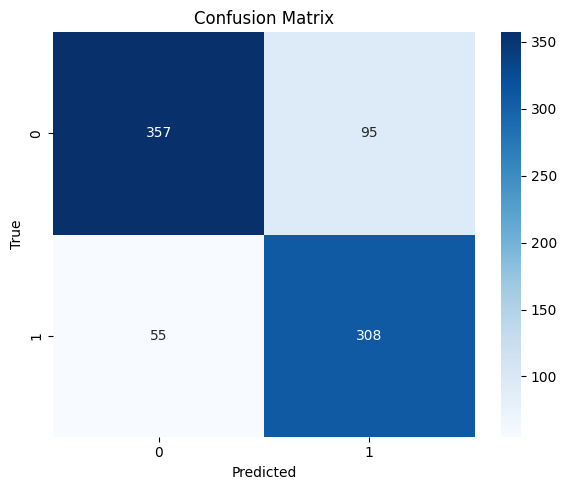

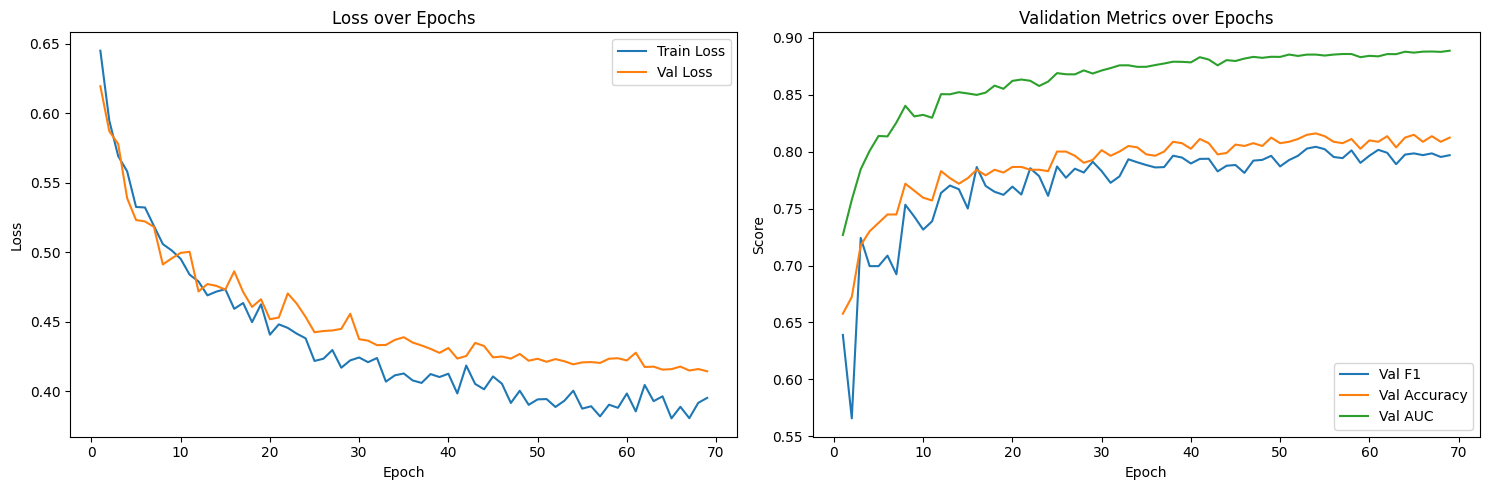

📁 Training history saved to training_history_fold2.csv

====================== Fold 3 ======================


Streaming output truncated to the last 5000 lines.
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:29:58] DEPRECATION WARNING: please use GetValence(getExplicit=False)


[Epoch 1] Train Loss: 0.6439 | Val Loss: 0.6113 | Acc: 0.6773 | F1: 0.5845 | AUC: 0.7190
✅ Saved new best model (epoch 1) - f1: 0.5845
[Epoch 2] Train Loss: 0.5974 | Val Loss: 0.5732 | Acc: 0.7055 | F1: 0.6375 | AUC: 0.7683
✅ Saved new best model (epoch 2) - f1: 0.6375
[Epoch 3] Train Loss: 0.5767 | Val Loss: 0.5447 | Acc: 0.7337 | F1: 0.6869 | AUC: 0.8016
✅ Saved new best model (epoch 3) - f1: 0.6869
[Epoch 4] Train Loss: 0.5461 | Val Loss: 0.5280 | Acc: 0.7669 | F1: 0.7301 | AUC: 0.8207
✅ Saved new best model (epoch 4) - f1: 0.7301
[Epoch 5] Train Loss: 0.5366 | Val Loss: 0.5124 | Acc: 0.7595 | F1: 0.7066 | AUC: 0.8286
🤷 No improvement in f1. Patience: 1/15
[Epoch 6] Train Loss: 0.5209 | Val Loss: 0.5035 | Acc: 0.7583 | F1: 0.7411 | AUC: 0.8333
✅ Saved new best model (epoch 6) - f1: 0.7411
[Epoch 7] Train Loss: 0.5170 | Val Loss: 0.4907 | Acc: 0.7693 | F1: 0.7520 | AUC: 0.8479
✅ Saved new best model (epoch 7) - f1: 0.7520
[Epoch 8] Train Loss: 0.5094 | Val Loss: 0.4782 | Acc: 0.7779 

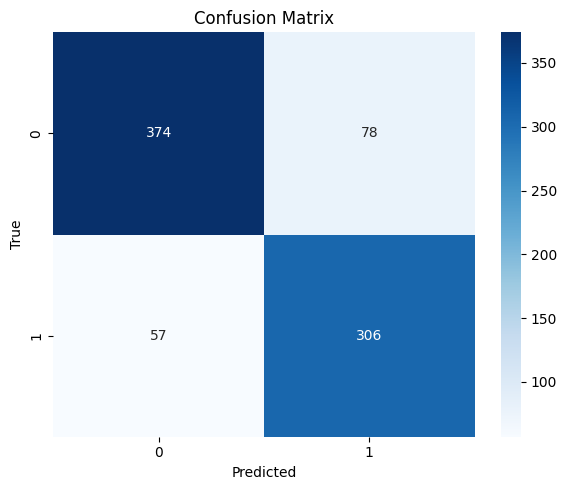

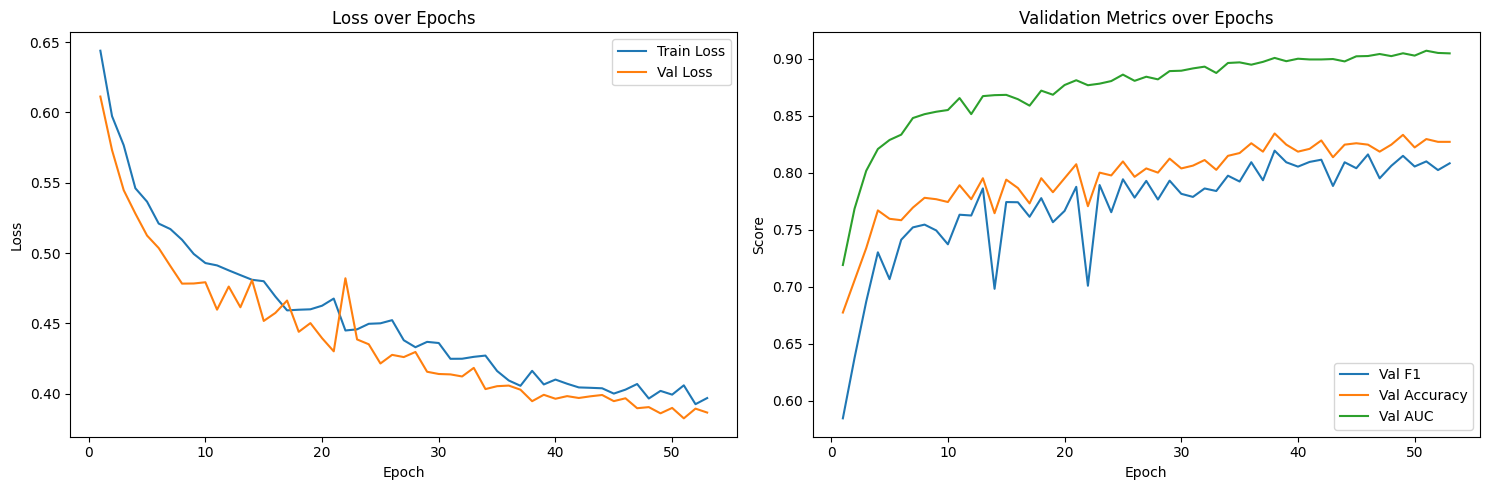

📁 Training history saved to training_history_fold3.csv

====================== Fold 4 ======================


Streaming output truncated to the last 5000 lines.
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:30:47] DEPRECATION WARNING: please use GetValence(getExplicit=False)


[Epoch 1] Train Loss: 0.6509 | Val Loss: 0.5922 | Acc: 0.7178 | F1: 0.6472 | AUC: 0.7710
✅ Saved new best model (epoch 1) - f1: 0.6472
[Epoch 2] Train Loss: 0.5893 | Val Loss: 0.5496 | Acc: 0.7264 | F1: 0.6754 | AUC: 0.7978
✅ Saved new best model (epoch 2) - f1: 0.6754
[Epoch 3] Train Loss: 0.5570 | Val Loss: 0.5347 | Acc: 0.7423 | F1: 0.6828 | AUC: 0.8208
✅ Saved new best model (epoch 3) - f1: 0.6828
[Epoch 4] Train Loss: 0.5433 | Val Loss: 0.5233 | Acc: 0.7436 | F1: 0.7133 | AUC: 0.8252
✅ Saved new best model (epoch 4) - f1: 0.7133
[Epoch 5] Train Loss: 0.5260 | Val Loss: 0.5344 | Acc: 0.7399 | F1: 0.7310 | AUC: 0.8235
✅ Saved new best model (epoch 5) - f1: 0.7310
[Epoch 6] Train Loss: 0.5262 | Val Loss: 0.5110 | Acc: 0.7521 | F1: 0.7292 | AUC: 0.8331
🤷 No improvement in f1. Patience: 1/15
[Epoch 7] Train Loss: 0.5147 | Val Loss: 0.5292 | Acc: 0.7301 | F1: 0.7317 | AUC: 0.8341
✅ Saved new best model (epoch 7) - f1: 0.7317
[Epoch 8] Train Loss: 0.5036 | Val Loss: 0.5477 | Acc: 0.7117 

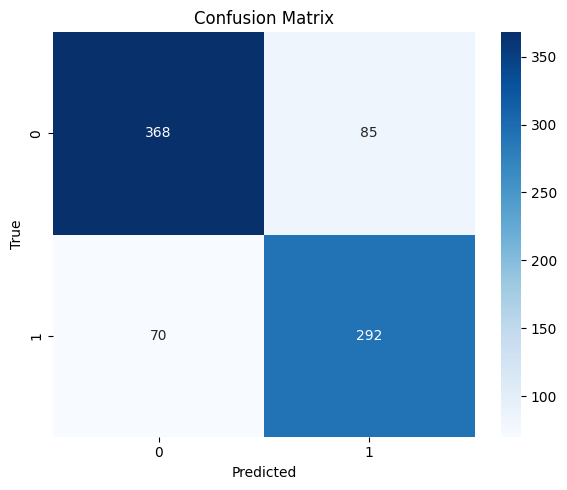

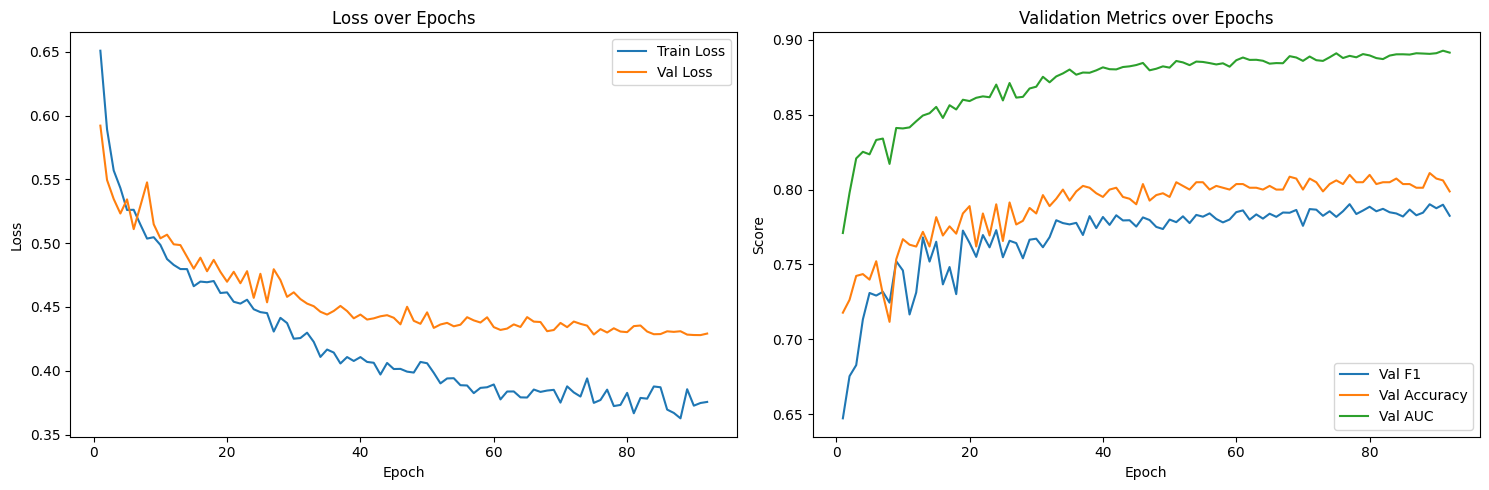

📁 Training history saved to training_history_fold4.csv

====================== Fold 5 ======================


Streaming output truncated to the last 5000 lines.
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:32:04] DEPRECATION WARNING: please use GetValence(getExplicit=False)


[Epoch 1] Train Loss: 0.6503 | Val Loss: 0.6020 | Acc: 0.6896 | F1: 0.6195 | AUC: 0.7391
✅ Saved new best model (epoch 1) - f1: 0.6195
[Epoch 2] Train Loss: 0.5949 | Val Loss: 0.5647 | Acc: 0.6994 | F1: 0.6282 | AUC: 0.7813
✅ Saved new best model (epoch 2) - f1: 0.6282
[Epoch 3] Train Loss: 0.5674 | Val Loss: 0.5450 | Acc: 0.7104 | F1: 0.6391 | AUC: 0.8009
✅ Saved new best model (epoch 3) - f1: 0.6391
[Epoch 4] Train Loss: 0.5531 | Val Loss: 0.5225 | Acc: 0.7436 | F1: 0.6984 | AUC: 0.8178
✅ Saved new best model (epoch 4) - f1: 0.6984
[Epoch 5] Train Loss: 0.5296 | Val Loss: 0.5177 | Acc: 0.7436 | F1: 0.6750 | AUC: 0.8308
🤷 No improvement in f1. Patience: 1/15
[Epoch 6] Train Loss: 0.5269 | Val Loss: 0.5012 | Acc: 0.7620 | F1: 0.7205 | AUC: 0.8369
✅ Saved new best model (epoch 6) - f1: 0.7205
[Epoch 7] Train Loss: 0.5070 | Val Loss: 0.4983 | Acc: 0.7558 | F1: 0.7161 | AUC: 0.8376
🤷 No improvement in f1. Patience: 1/15
[Epoch 8] Train Loss: 0.5176 | Val Loss: 0.4929 | Acc: 0.7485 | F1: 0

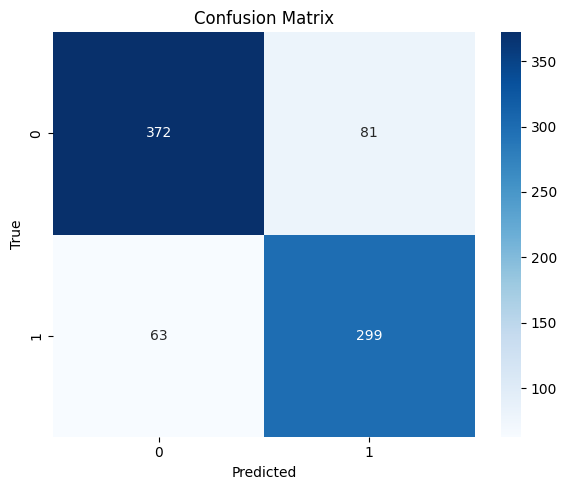

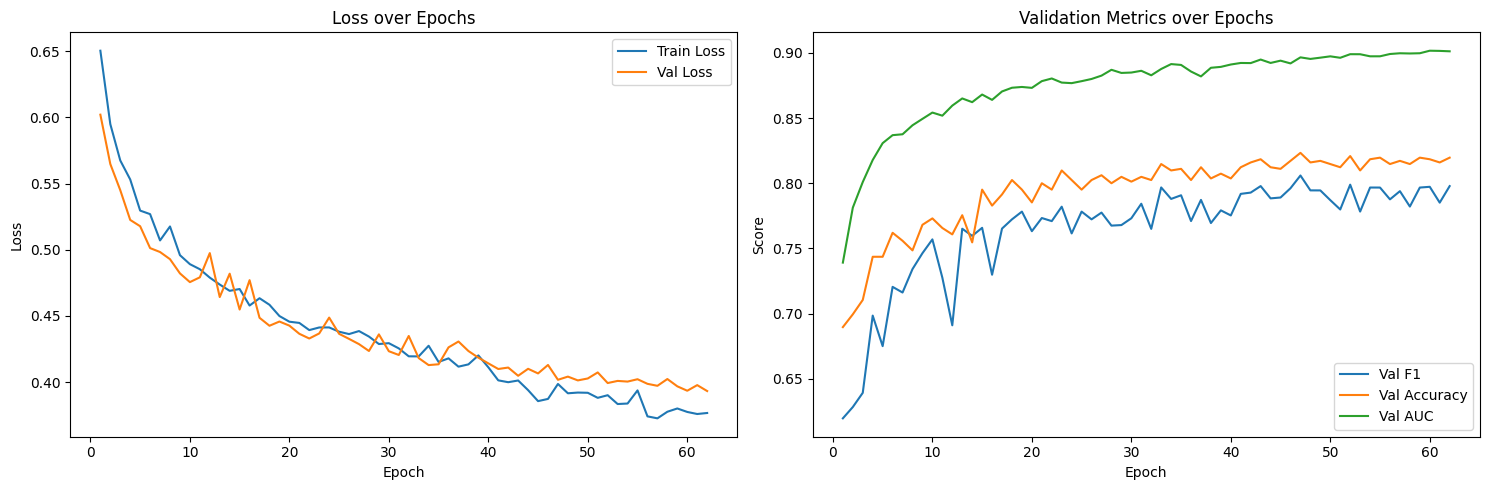

📁 Training history saved to training_history_fold5.csv

========== Cross-Validation Summary ==========
   fold   best_f1  best_auc  best_acc  min_val_loss
0     1  0.813738  0.901076  0.826994      0.405044
1     2  0.804178  0.888521  0.815951      0.414492
2     3  0.819277  0.906915  0.834356      0.382378
3     4  0.790257  0.892729  0.811043      0.427946
4     5  0.805930  0.901711  0.823313      0.393253

Average Scores:
best_f1         0.806676
best_auc        0.898190
best_acc        0.822331
min_val_loss    0.404623
dtype: float64


In [ ]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate model
model = DeepChemStyleGraphConv(node_feat_dim=75, n_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Assume now we have:
# model, optimizer, criterion, train_loader, val_loader, device

from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_histories = []
fold_metrics = []

for fold, (train_index, val_index) in enumerate(skf.split(smiles_list, labels), start=1):
    print(f"\n====================== Fold {fold} ======================")

    # Split data
    smiles_train = [smiles_list[i] for i in train_index]
    labels_train = [labels[i] for i in train_index]
    smiles_val = [smiles_list[i] for i in val_index]
    labels_val = [labels[i] for i in val_index]

    # Convert to graph
    train_graphs = convmol_to_pyg(smiles_train, labels_train)
    val_graphs = convmol_to_pyg(smiles_val, labels_val)

    # Create DataLoaders
    train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=32)

    # Instantiate new model for each fold
    model = DeepChemStyleGraphConv(node_feat_dim=75, n_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = torch.nn.CrossEntropyLoss()

    # Train
    history = run_training_loop_with_early_stopping(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=100,
        save_path=f'model_fold{fold}.pt',
        is_binary=True,
        monitor_metric='f1',
        early_stopping_patience=15,
        lr_scheduler_patience=7,
        csv_path=f'training_history_fold{fold}.csv'
    )

    fold_histories.append(history)
    fold_metrics.append({
        'fold': fold,
        'best_f1': max(history['val_f1']),
        'best_auc': max(history['val_auc']),
        'best_acc': max(history['val_acc']),
        'min_val_loss': min(history['val_loss']),
    })

# Summary across folds
print("\n========== Cross-Validation Summary ==========")
cv_results = pd.DataFrame(fold_metrics)
print(cv_results)
print("\nAverage Scores:")
print(cv_results[['best_f1', 'best_auc', 'best_acc', 'min_val_loss']].mean())


In [ ]:
from torch_geometric.data import Data
import torch.nn as nn

class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, batch):
        data = Data(x=x, edge_index=edge_index, batch=batch)
        out = self.model(data)
        return out  # must return raw logits


# import trained model

In [ ]:
# Reconstruct model and load saved weights
model = DeepChemStyleGraphConv(node_feat_dim=75, n_classes=2).to(device)
model.load_state_dict(torch.load("model_fold2.pt", map_location=device))
model.eval()

DeepChemStyleGraphConv(
  (convs): ModuleList(
    (0): GraphConv(75, 64)
    (1): GraphConv(64, 64)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer

wrapped_model = WrappedModel(model).to(device)

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='binary_classification',  # or 'multiclass_classification'
        task_level='graph',
        return_type='raw',
    )
)


In [ ]:
from torch_geometric.loader import DataLoader

# Get a single graph from val_loader (not a batch!)
val_graph = val_graphs[0]  # or pick a specific graph index
val_graph = val_graph.to(device)
print(f"SMILES string for the explained molecule: {val_graph.smiles}")

SMILES string for the explained molecule: COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2


In [ ]:
explanation = explainer(
    x=val_graph.x,
    edge_index=val_graph.edge_index,
    batch=torch.zeros(val_graph.x.size(0), dtype=torch.long).to(device)  # single graph → batch of 0s
)

In [ ]:
print(explanation)

Explanation(node_mask=[40, 75], edge_mask=[90], prediction=[1, 2], target=[2], x=[40, 75], edge_index=[2, 90], batch=[40])


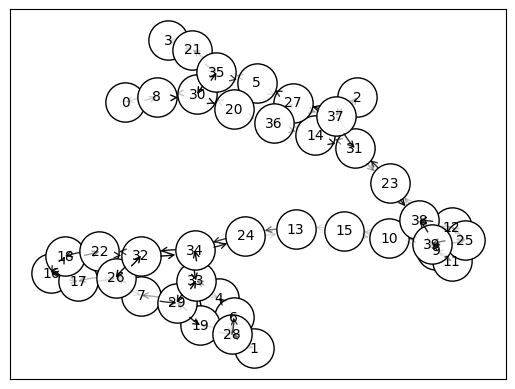

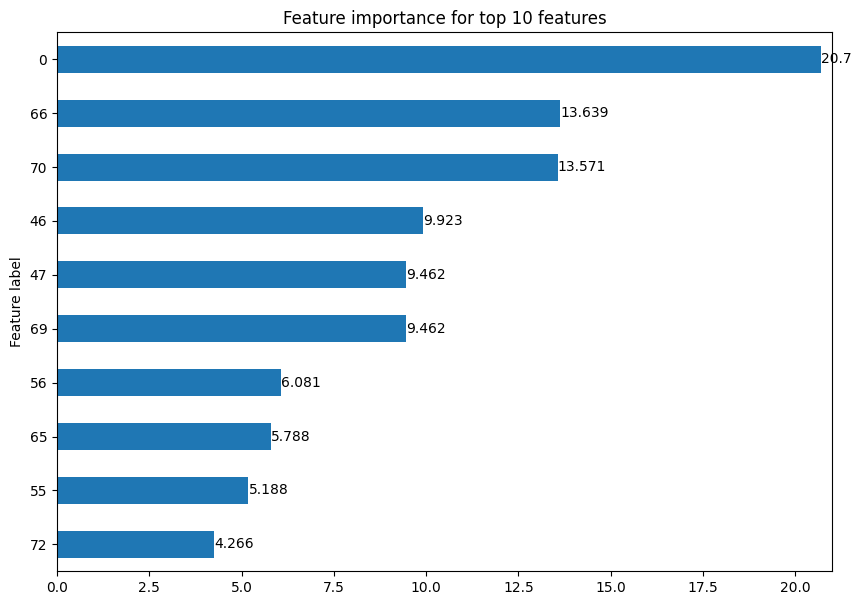

In [ ]:
# Generate explanation
explanation = explainer(
    x=val_graph.x,
    edge_index=val_graph.edge_index,
    batch=torch.zeros(val_graph.x.size(0), dtype=torch.long).to(device)
)

# Visualize graph with edge importance
explanation.visualize_graph(backend='networkx')

# Visualize top-10 most important input features
explanation.visualize_feature_importance(top_k=10)

In [ ]:
from deepchem.feat import ConvMolFeaturizer
from rdkit import Chem

# Example molecule
mol = Chem.MolFromSmiles("COc1cccc(CN2CCC(/C=C3\\Cc4cccc(OC)c4C3=O)CC2)c1")
featurizer = ConvMolFeaturizer()
mol_graph = featurizer.featurize([mol])[0]

# Look at atom 0's feature vector
atom_feat_vector = mol_graph.get_atom_features()[0]

# Print feature vector with index
for idx, val in enumerate(atom_feat_vector):
    print(f"Feature {idx}: {val}")

Feature 0: 1.0
Feature 1: 0.0
Feature 2: 0.0
Feature 3: 0.0
Feature 4: 0.0
Feature 5: 0.0
Feature 6: 0.0
Feature 7: 0.0
Feature 8: 0.0
Feature 9: 0.0
Feature 10: 0.0
Feature 11: 0.0
Feature 12: 0.0
Feature 13: 0.0
Feature 14: 0.0
Feature 15: 0.0
Feature 16: 0.0
Feature 17: 0.0
Feature 18: 0.0
Feature 19: 0.0
Feature 20: 0.0
Feature 21: 0.0
Feature 22: 0.0
Feature 23: 0.0
Feature 24: 0.0
Feature 25: 0.0
Feature 26: 0.0
Feature 27: 0.0
Feature 28: 0.0
Feature 29: 0.0
Feature 30: 0.0
Feature 31: 0.0
Feature 32: 0.0
Feature 33: 0.0
Feature 34: 0.0
Feature 35: 0.0
Feature 36: 0.0
Feature 37: 0.0
Feature 38: 0.0
Feature 39: 0.0
Feature 40: 0.0
Feature 41: 0.0
Feature 42: 0.0
Feature 43: 0.0
Feature 44: 0.0
Feature 45: 1.0
Feature 46: 0.0
Feature 47: 0.0
Feature 48: 0.0
Feature 49: 0.0
Feature 50: 0.0
Feature 51: 0.0
Feature 52: 0.0
Feature 53: 0.0
Feature 54: 0.0
Feature 55: 0.0
Feature 56: 0.0
Feature 57: 0.0
Feature 58: 1.0
Feature 59: 0.0
Feature 60: 0.0
Feature 61: 0.0
Feature 62: 0.0
Fe

[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[16:53:24] DEPRECATION WARNING: please use GetValen

In [ ]:
node_importance = explanation.node_mask.sum(dim=1).detach().cpu().numpy()  # shape: (num_nodes,)

print(node_importance)

[2.1643643 3.5187054 2.9320202 2.3012118 3.088387  3.7454646 3.0286565
 2.9316807 1.7463136 2.5548606 2.6817734 1.8225043 2.6824858 2.5021234
 2.3921928 2.5588408 3.022515  2.674534  2.9700725 3.5428762 3.8130212
 1.844093  2.4783072 2.4884577 2.9755714 2.5532117 3.7060168 2.9067197
 3.0993013 3.2119353 2.8896272 3.2458673 2.962232  2.866315  3.6525245
 2.6267357 2.8143017 2.398696  2.7515197 2.6464531]


In [ ]:
# Run GNNExplainer
explanation = explainer(
    x=val_graph.x,
    edge_index=val_graph.edge_index,
    batch=torch.zeros(val_graph.x.size(0), dtype=torch.long).to(device)
)

# Compute model prediction manually
with torch.no_grad():
    logits = model(val_graph)
    pred_class = logits.argmax(dim=1)  # shape: [1]
    explanation.y = pred_class  # Add to explanation

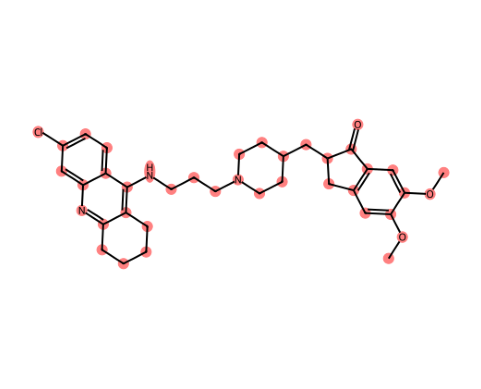

In [ ]:
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

def visualize_atom_importance(smiles, importance_scores, figsize=(500, 400)):
    mol = Chem.MolFromSmiles(smiles)
    num_atoms = mol.GetNumAtoms()

    # Normalize importance scores to [0, 1]
    max_val = max(importance_scores)
    min_val = min(importance_scores)
    norm_scores = [(x - min_val) / (max_val - min_val + 1e-6) for x in importance_scores]

    # Create color map for atoms
    atom_colors = {i: (1.0, 1.0 - s, 1.0 - s) for i, s in enumerate(norm_scores)}  # red = important

    # Draw molecule with highlights
    img = Draw.MolToImage(mol, size=figsize, highlightAtoms=list(atom_colors.keys()),
                          highlightAtomColors=atom_colors)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

visualize_atom_importance(val_graph.smiles, node_importance)

In [ ]:
explanation.visualize_graph(path='explained_graph.png')
explanation.visualize_feature_importance(path='feature_importance.png', top_k=10)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
import numpy as np

def visualize_explained_molecule(explanation, smiles: str, edge_threshold=0.1):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES:", smiles)

    edge_index = explanation.edge_index.cpu().numpy()
    edge_mask = explanation.edge_mask.cpu().detach().numpy()

    # Normalize edge mask
    edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)

    # RDKit uses bond indices, not edge_index, so we must map PyG edges to RDKit bonds
    bond_weights = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Find corresponding index in edge_index
        for idx, (u, v) in enumerate(edge_index.T):  # shape [2, num_edges]
            if (u == i and v == j) or (u == j and v == i):
                bond_weights[bond.GetIdx()] = edge_mask[idx]
                break

    # Highlighting setup
    highlight_bonds = [k for k, v in bond_weights.items() if v > edge_threshold]
    bond_colors = {k: (1 - v, v, 0.0) for k, v in bond_weights.items()}  # RGB: green-red

    drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
    drawer.DrawMolecule(
        mol,
        highlightBonds=highlight_bonds,
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()

    png = drawer.GetDrawingText()
    from PIL import Image
    import io
    return Image.open(io.BytesIO(png))

# explain a single graph

In [ ]:
# Assume val_graphs is your list of Data objects (with smiles)
val_graph = val_graphs[0]
val_graph = val_graph.to(device)

# Create dummy batch vector for single graph
batch = torch.zeros(val_graph.num_nodes, dtype=torch.long).to(device)

# Run explainer
explanation = explainer(
    x=val_graph.x,
    edge_index=val_graph.edge_index,
    batch=batch
)

In [ ]:
print(f"SMILES string for the explained molecule: {val_graph.smiles}")

SMILES string for the explained molecule: COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2


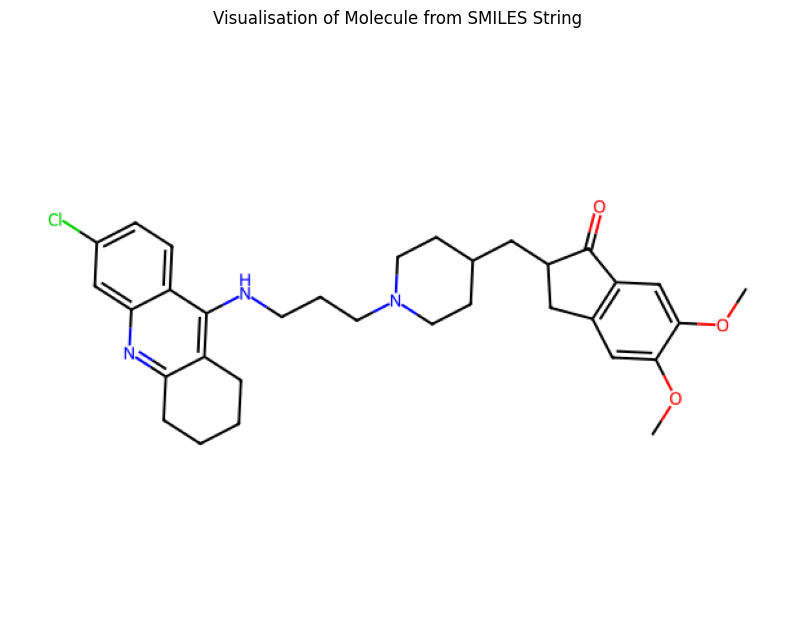

In [ ]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw

# The SMILES string for the molecule
smiles_string = "COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2"

try:
    # Create the RDKit molecule object from the SMILES string
    rdkit_mol = Chem.MolFromSmiles(smiles_string)

    if rdkit_mol is None:
        print(f"Error: Could not parse SMILES string '{smiles_string}'")
    else:
        # Optionally, add explicit hydrogens for a more complete structural view.
        # This is not strictly necessary for basic visualization, but can be useful.
        # rdkit_mol = Chem.AddHs(rdkit_mol)

        # Generate the image of the molecule
        # Setting a larger size for better clarity of a complex molecule
        img = Draw.MolToImage(rdkit_mol, size=(600, 450))

        # Display the image using Matplotlib
        plt.figure(figsize=(10, 8)) # Adjust figure size for better display
        plt.imshow(img)
        plt.axis('off') # Hide axes
        plt.title("Visualisation of Molecule from SMILES String")
        plt.show()

except Exception as e:
    print(f"An error occurred during visualization: {e}")
    print("Please ensure the RDKit library is installed and the SMILES string is valid.")



## visualize

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw.rdMolDraw2D import MolDraw2DCairo
import numpy as np
from PIL import Image
import io

def visualize_explained_molecule_with_nodes_and_edges(explanation, smiles: str, edge_threshold=0.1, node_threshold=0.1):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES:", smiles)

    # ---- Edge mask handling ----
    edge_index = explanation.edge_index.cpu().numpy()
    edge_mask = explanation.edge_mask.cpu().detach().numpy()

    # Normalize edge mask
    edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)

    # Map to RDKit bond indices
    bond_weights = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        scores = [
            float(edge_mask[idx]) for idx, (u, v) in enumerate(edge_index.T)
            if (u == i and v == j) or (u == j and v == i)
        ]
        if scores:
            bond_weights[bond.GetIdx()] = np.mean(scores)

    highlight_bonds = [k for k, v in bond_weights.items() if v > edge_threshold]
    bond_colors = {k: (float(1 - v), float(v), 0.0) for k, v in bond_weights.items()}

    # ---- Node mask handling ----
    if hasattr(explanation, 'node_mask') and explanation.node_mask is not None:
        node_mask = explanation.node_mask.cpu().detach().numpy()

        if len(node_mask.shape) == 2:  # [num_nodes, num_features]
            node_mask = node_mask.sum(axis=1)

        # Normalize
        node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min() + 1e-10)

        highlight_atoms = [i for i, v in enumerate(node_mask) if v > node_threshold]
        atom_colors = {i: (float(1 - v), float(v), 0.0) for i, v in enumerate(node_mask) if v > node_threshold}
    else:
        highlight_atoms = []
        atom_colors = {}

    # ---- Draw the molecule ----
    drawer = MolDraw2DCairo(400, 400)
    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightBonds=highlight_bonds,
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()

    png = drawer.GetDrawingText()
    return Image.open(io.BytesIO(png))

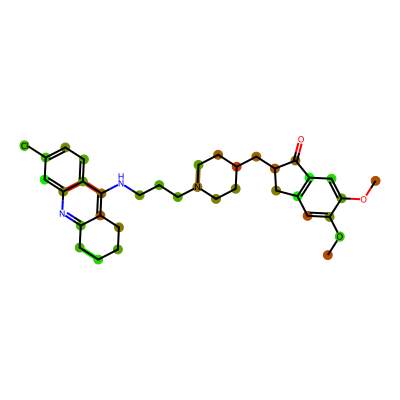

In [ ]:
img = visualize_explained_molecule_with_nodes_and_edges(
    explanation,
    smiles=val_graph.smiles,
    edge_threshold=0.1,
    node_threshold=0.1
)
display(img)

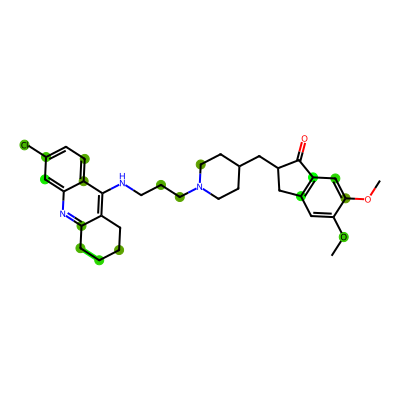

In [ ]:
img = visualize_explained_molecule_with_nodes_and_edges(
    explanation,
    smiles=val_graph.smiles,
    edge_threshold=0.6,
    node_threshold=0.6
)
display(img)

## explain using sentence (also cross-checking)

In [ ]:
def extract_explanation_sentence(explanation, mol, class_names=["Negative", "Positive"],
                                 node_threshold=0.1, edge_threshold=0.1, top_k=3):
    atom_names = [atom.GetSymbol() for atom in mol.GetAtoms()]
    sentences = []

    # --- Node mask (atom importance) ---
    node_mask = explanation.node_mask
    if node_mask is not None:
        node_mask = node_mask.cpu().detach().numpy()
        if node_mask.ndim == 2:
            node_mask = node_mask.sum(axis=1)
        node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min() + 1e-10)

        important_atoms = [(i, float(score)) for i, score in enumerate(node_mask) if score > node_threshold]
        important_atoms = sorted(important_atoms, key=lambda x: x[1], reverse=True)
        if important_atoms:
            atom_desc = ", ".join(
                [f"{atom_names[i]} (index {i}, score {score:.2f})" for i, score in important_atoms[:top_k]]
            )
            sentences.append(f"The model focused on the following atoms: {atom_desc}.")

    # --- Edge mask (bond importance) with bidirectional averaging ---
    edge_mask = explanation.edge_mask
    if edge_mask is not None:
        edge_mask = edge_mask.cpu().detach().numpy()
        edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)
        edge_index = explanation.edge_index.cpu().numpy()

        bond_weights = {}
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            scores = [
                float(edge_mask[idx]) for idx, (u, v) in enumerate(edge_index.T)
                if (u == i and v == j) or (u == j and v == i)
            ]
            if scores:
                bond_weights[(i, j)] = np.mean(scores)

        important_bonds = [(i, j, score) for (i, j), score in bond_weights.items() if score > edge_threshold]
        important_bonds = sorted(important_bonds, key=lambda x: x[2], reverse=True)
        if important_bonds:
            bond_desc = ", ".join(
                [f"{atom_names[i]}-{atom_names[j]} (indices {i}-{j}, score {score:.2f})"
                 for i, j, score in important_bonds[:top_k]]
            )
            sentences.append(f"The most influential bonds include: {bond_desc}.")

    # --- Classification result ---
    pred_label = None
    if hasattr(explanation, "y") and explanation.y is not None:
        try:
            pred_label = int(explanation.y.item())
        except Exception as e:
            print(f"Warning: explanation.y exists but could not be interpreted: {e}")

    if pred_label is None and hasattr(explanation, "prediction") and explanation.prediction is not None:
        try:
            pred_label = int(explanation.prediction.argmax().item())
        except Exception as e:
            print(f"Warning: explanation.prediction fallback also failed: {e}")

    if pred_label is not None:
        class_str = class_names[pred_label] if pred_label < len(class_names) else str(pred_label)
        sentences.append(f"The model predicted this molecule as **{class_str}**.")

    if not sentences:
        return "No explanation information could be extracted."

    return " ".join(sentences)


In [ ]:
from rdkit import Chem

mol = Chem.MolFromSmiles(val_graph.smiles)
sentence = extract_explanation_sentence(
    explanation,
    mol,
    class_names=["Non-ACHE", "ACHE Inhibitor"]
)
print(sentence)

The model focused on the following atoms: C (index 5, score 1.00), C (index 4, score 0.92), C (index 27, score 0.92). The most influential bonds include: C-C (indices 33-34, score 0.94), C-N (indices 16-17, score 0.43), C-C (indices 32-22, score 0.17). The model predicted this molecule as **ACHE Inhibitor**.


## with index visible

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import Draw
from IPython.display import Image as IPyImage
import io
import numpy as np

def visualize_and_explain_molecule_with_indices(model, data, explanation,
                                                class_names=["Class 0", "Class 1"],
                                                node_threshold=0.1,
                                                edge_threshold=0.1,
                                                return_sentence=True,
                                                image_size=(700, 700)):
    smiles = data.smiles
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string.")

    atom_names = [atom.GetSymbol() for atom in mol.GetAtoms()]

    # --- Node mask ---
    node_mask = explanation.node_mask
    if node_mask is not None:
        node_mask = node_mask.cpu().detach().numpy()
        if node_mask.ndim == 2:
            node_mask = node_mask.sum(axis=1)
        node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min() + 1e-10)
        highlight_atoms = [i for i, score in enumerate(node_mask) if score > node_threshold]
        atom_colors = {i: (1 - float(score), float(score), 0.0) for i, score in enumerate(node_mask)}
    else:
        highlight_atoms = []
        atom_colors = {}

    # --- Edge mask ---
    edge_index = explanation.edge_index.cpu().numpy()
    edge_mask = explanation.edge_mask.cpu().detach().numpy()
    edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)

    bond_weights = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        scores = [float(edge_mask[idx]) for idx, (u, v) in enumerate(edge_index.T)
                  if (u == i and v == j) or (u == j and v == i)]

        if scores:
            bond_weights[bond.GetIdx()] = np.mean(scores)

    highlight_bonds = [k for k, v in bond_weights.items() if v > edge_threshold]
    bond_colors = {k: (1 - float(v), float(v), 0.0) for k, v in bond_weights.items()}

    # --- Draw molecule ---
    width, height = image_size
    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    drawer.drawOptions().addAtomIndices = True
    drawer.drawOptions().fixedScale = 1.5
    drawer.drawOptions().padding = 0.1
    drawer.drawOptions().highlightBondWidthMultiplier = 16  # thicker highlights

    drawer.DrawMolecule(mol,
                        highlightAtoms=highlight_atoms,
                        highlightAtomColors=atom_colors,
                        highlightBonds=highlight_bonds,
                        highlightBondColors=bond_colors)
    drawer.FinishDrawing()

    img_bytes = drawer.GetDrawingText()
    img = IPyImage(data=img_bytes)

    # --- Generate explanation sentence ---
    sentences = []

    if highlight_atoms:
        top_atoms = sorted([(i, node_mask[i]) for i in highlight_atoms], key=lambda x: -x[1])
        atom_desc = ", ".join([f"{atom_names[i]} (index {i}, score {score:.2f})" for i, score in top_atoms[:3]])
        sentences.append(f"The model focused on the following atoms: {atom_desc}.")

    if bond_weights:
        top_bonds = sorted(bond_weights.items(), key=lambda x: -x[1])
        top_bond_desc = []
        for bond_idx, score in top_bonds[:3]:
            bond = mol.GetBondWithIdx(bond_idx)
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bond_str = f"{atom_names[i]}-{atom_names[j]} (indices {i}-{j}, score {score:.2f})"
            top_bond_desc.append(bond_str)
        if top_bond_desc:
            sentences.append(f"The most influential bonds include: {', '.join(top_bond_desc)}.")

    if hasattr(explanation, "y") and explanation.y is not None:
        try:
            pred_label = int(explanation.y.item())
            class_str = class_names[pred_label] if pred_label < len(class_names) else str(pred_label)
            sentences.append(f"The model predicted this molecule as **{class_str}**.")
        except Exception as e:
            sentences.append("Prediction could not be parsed.")

    sentence_output = " ".join(sentences)

    if return_sentence:
        return img, sentence_output
    else:
        return img


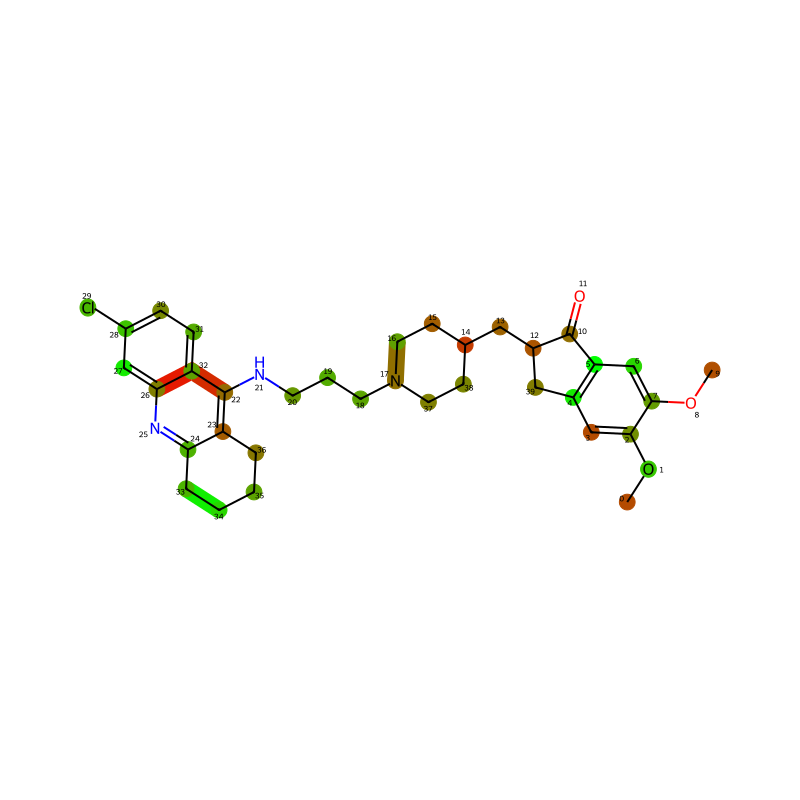

The model focused on the following atoms: C (index 5, score 1.00), C (index 4, score 0.92), C (index 27, score 0.92). The most influential bonds include: C-C (indices 33-34, score 0.94), C-N (indices 16-17, score 0.43), C-C (indices 32-22, score 0.17).


In [ ]:
fig, sentence = visualize_and_explain_molecule_with_indices(
    model, val_graph, explanation,
    class_names=["Non-ACHE", "ACHE Inhibitor"],
    return_sentence=True,
    image_size=(800, 800)
)

display(fig)
print(sentence)
